# 08 · Linear least squares: calibrating a thermocouple

**Problem.** A thermocouple is calibrated against a reference thermometer. We need the relation
between its voltage (mV) and temperature, how good it is, and how to use it in reverse. The
calibration readings are in the file `thermocouple_calibration.csv` (synthetic data resembling a
type-K thermocouple), loaded with `np.loadtxt`.

"Linear" least squares means linear in the **coefficients**: $E = a_0 + a_1 T + a_2 T^2$ is a linear
model even though it is curved in $T$.

**What you will learn**

- fit models that are linear in their coefficients
- compute least squares via the normal equations and via QR, with standard errors
- judge a model from residual plots and coefficient confidence intervals
- use robust regression to flag outliers

**Before you start:** notebooks 00 and 03; standard deviation and confidence intervals  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import fitting

In [2]:
from engmath import datasets
cal = np.loadtxt(datasets.path("thermocouple_calibration.csv"), delimiter=",", skiprows=1)
T_ref, E = cal[:, 0], cal[:, 1]                       # reference temperature (°C), voltage (mV)
X1 = np.column_stack([np.ones_like(T_ref), T_ref])
X2 = np.column_stack([np.ones_like(T_ref), T_ref, T_ref**2])
lin, quad = fitting.linear_lstsq(X1, E), fitting.linear_lstsq(X2, E)
for name, f in (("linear", lin), ("quadratic", quad)):
    ci = f.conf_int()
    print(f"{name:<9} coefficients {np.array2string(f.coef, precision=6)}  residual SD {f.sigma*1000:.1f} µV")
print(f"quadratic term: {quad.coef[2]:.2e}, 95 % CI [{quad.conf_int()[2,0]:.2e}, {quad.conf_int()[2,1]:.2e}]")

linear    coefficients [-0.02943   0.040089]  residual SD 29.6 µV
quadratic coefficients [1.044802e-02 3.940549e-02 1.709042e-06]  residual SD 9.1 µV
quadratic term: 1.71e-06, 95 % CI [1.20e-06, 2.22e-06]


The residual standard deviation drops sharply and the confidence interval of the quadratic term
excludes zero: the curvature is real. **Residual plots** show it directly:

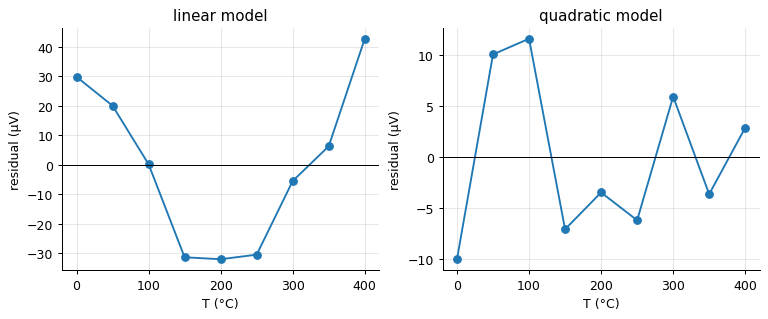

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, f, name in ((a1, lin, "linear"), (a2, quad, "quadratic")):
    ax.plot(T_ref, f.residuals*1000, "o-"); ax.axhline(0, color="k", lw=0.8)
    ax.set(xlabel="T (°C)", ylabel="residual (µV)", title=f"{name} model")
plt.show()

## Inside the algorithm: least squares in a few lines
Minimising $\lVert\mathbf y - X\mathbf b\rVert^2$ leads to the normal equations $X^TX\,\mathbf b = X^T\mathbf y$.
A QR factorisation $X = QR$ solves the same problem as $R\,\mathbf b = Q^T\mathbf y$ without forming
$X^TX$. The standard errors follow from $s^2 (X^TX)^{-1}$, where $s$ is the residual standard deviation:

In [4]:
b_normal = np.linalg.solve(X2.T @ X2, X2.T @ E)          # normal equations
Q, Rm = np.linalg.qr(X2)
b_qr = np.linalg.solve(Rm, Q.T @ E)                      # QR factorisation
s = np.sqrt(np.sum((E - X2 @ b_qr)**2) / (len(E) - 3))   # residual standard deviation, n - p dof
se = s * np.sqrt(np.diag(np.linalg.inv(X2.T @ X2)))
print("normal equations:", b_normal)
print("QR:              ", b_qr)
print("library:         ", quad.coef)
print("standard errors: ", se, "  library:", quad.se)

normal equations: [1.04480235e-02 3.94054884e-02 1.70904176e-06]
QR:               [1.04480235e-02 3.94054884e-02 1.70904176e-06]
library:          [1.04480235e-02 3.94054884e-02 1.70904176e-06]
standard errors:  [7.38109039e-03 8.60493577e-05 2.06982620e-07]   library: [7.38109039e-03 8.60493577e-05 2.06982620e-07]


A systematic arch in the residuals means the model is missing a term; random scatter means it
captures the physics.

## How the fit is computed - and why not the textbook formula
The normal equations $\mathbf{b} = (X^TX)^{-1}X^T\mathbf{y}$ square the condition number of $X$.
`engmath` uses a QR factorisation instead. With raw temperatures the columns $1, T, T^2$ differ by
five orders of magnitude:

In [5]:
for name, X in (("1, T, T²", X2), ("scaled: 1, t, t² with t = T/400", np.column_stack([np.ones(9), T_ref/400, (T_ref/400)**2]))):
    print(f"{name:<32} cond(X) = {np.linalg.cond(X):9.3g}   cond(XᵀX) = {np.linalg.cond(X.T @ X):9.3g}")

1, T, T²                         cond(X) =   1.9e+05   cond(XᵀX) =  3.62e+10
scaled: 1, t, t² with t = T/400  cond(X) =      18.9   cond(XᵀX) =       356


Each factor of 10 in the condition number can cost a digit of accuracy. Scaling or centring
predictors is cheap insurance.

## Using the calibration in reverse
In service we measure $E$ and need $T$: solve the fitted quadratic for $T$.

In [6]:
from engmath import roots
E_meas = 9.100
b0, b1, b2 = quad.coef
T_est = roots.brent(lambda T: b0 + b1*T + b2*T**2 - E_meas, 0, 450).root
print(f"E = {E_meas} mV  ->  T = {T_est:.2f} °C")

E = 9.1 mV  ->  T = 228.40 °C


For the uncertainty of such inverse predictions (and prediction bands), see
`engstat.regression.Calibration` in the companion statistics library.

## Robust fitting: one bad reading
A loose connector produces one wrong reading at 400 °C. Ordinary least squares lets it pull the
whole line; Huber's robust regression down-weights it automatically.

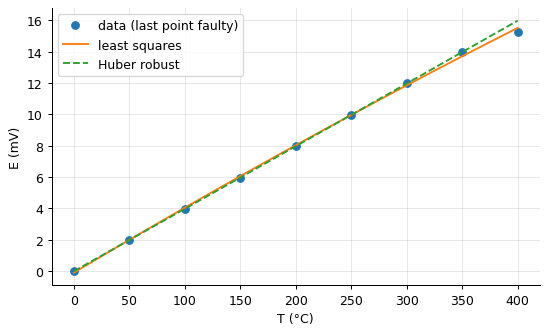

robust weights: [1.   1.   1.   1.   1.   1.   1.   0.73 0.04]
error at 300 °C: OLS 135 µV, robust 18 µV


In [7]:
E_bad = E.copy(); E_bad[-1] -= 0.8
ols = fitting.linear_lstsq(X2, E_bad)
rob = fitting.huber_irls(X2, E_bad)
TT = np.linspace(0, 400, 200); XX = np.column_stack([np.ones(200), TT, TT**2])
plt.plot(T_ref, E_bad, "o", label="data (last point faulty)")
plt.plot(TT, XX @ ols.coef, label="least squares"); plt.plot(TT, XX @ rob.coef, "--", label="Huber robust")
plt.xlabel("T (°C)"); plt.ylabel("E (mV)"); plt.legend(); plt.show()
print("robust weights:", np.round(rob.weights, 2))
print(f"error at 300 °C: OLS {abs(XX[150]@ols.coef - XX[150]@quad.coef)*1000:.0f} µV, robust {abs(XX[150]@rob.coef - XX[150]@quad.coef)*1000:.0f} µV")

Robust methods *flag* suspicious points (weight ≪ 1) - they do not excuse you from investigating
them.

## Exercises
1. Fit a cubic. Is the cubic term significant? What happens to the confidence intervals of the other
   coefficients, and why?
2. Refit the quadratic with only the points at or below 200 °C and use it to predict the voltage at
   400 °C. Compare with the full fit: the danger of extrapolation.
3. Linearise $k = A e^{-E_a/RT}$ as $\ln k$ vs $1/T$ and fit it with `linear_lstsq`. Why do the
   weights of the points change when you transform the data? (Preview of notebook 09.)
4. **Implement it yourself:** write the Huber IRLS loop: compute residuals $r$, a robust scale $s = \mathrm{MAD}/0.6745$, weights $w = \min(1, 1.345/|r/s|)$; refit by weighted least squares; repeat until the coefficients stop changing. Compare with `fitting.huber_irls`.